# Fake News Detection: Model Results

This notebook visualizes the TF-IDF + Logistic Regression and TF-IDF + Linear SVM scores saved by `src/train_baseline.py`. Run the training script first if `reports/baseline_metrics.json` is missing or you want to refresh the results. Install `requirements.txt`, then select the project Python kernel before running the cells.

The evaluation uses the same stratified 80/20 holdout split (seed 42) for both models.

In [1]:
from pathlib import Path
import json
import os
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'reports' / 'baseline_metrics.json').exists():
    ROOT = ROOT.parent  # allows opening the notebook from a notebooks/ subfolder
os.environ.setdefault('MPLCONFIGDIR', str(ROOT / 'work' / 'matplotlib_cache'))
import matplotlib.pyplot as plt
metrics_path = ROOT / 'reports' / 'baseline_metrics.json'
if not metrics_path.exists():
    raise FileNotFoundError('Run python src/train_baseline.py from the project folder first.')
metrics = json.loads(metrics_path.read_text(encoding='utf-8'))
models = metrics['models']
names = {'logistic_regression': 'Logistic Regression', 'linear_svm': 'Linear SVM'}
scores = pd.DataFrame([
    {'Model': names.get(name, name), 'Accuracy': result['accuracy'], 'Macro F1': result['macro_f1']}
    for name, result in models.items()
]).set_index('Model')
print(f"Test set: {metrics['test_rows']:,} articles | Best by macro F1: {names.get(metrics['best_model_by_macro_f1'], metrics['best_model_by_macro_f1'])}")
scores.mul(100).round(2).astype(str) + '%'

Test set: 1,819 articles | Best by macro F1: Linear SVM

                    Accuracy Macro F1
Model                                
Logistic Regression   96.26%   96.25%
Linear SVM            97.86%   97.85%

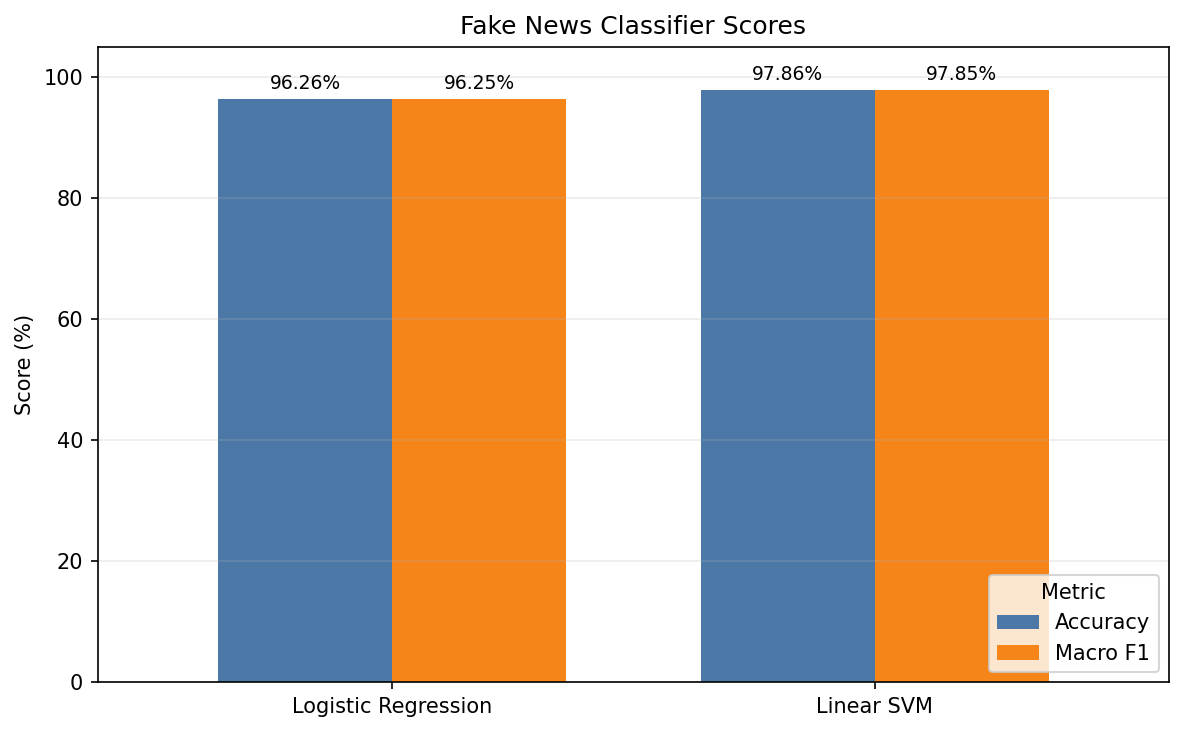

In [2]:
# Compare accuracy and macro F1 as percentages.
ax = (scores * 100).plot(kind='bar', figsize=(8, 5), width=0.72, color=['#4C78A8', '#F58518'])
ax.set_title('Fake News Classifier Scores')
ax.set_ylabel('Score (%)')
ax.set_xlabel('')
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.25)
ax.legend(title='Metric', loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3, fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

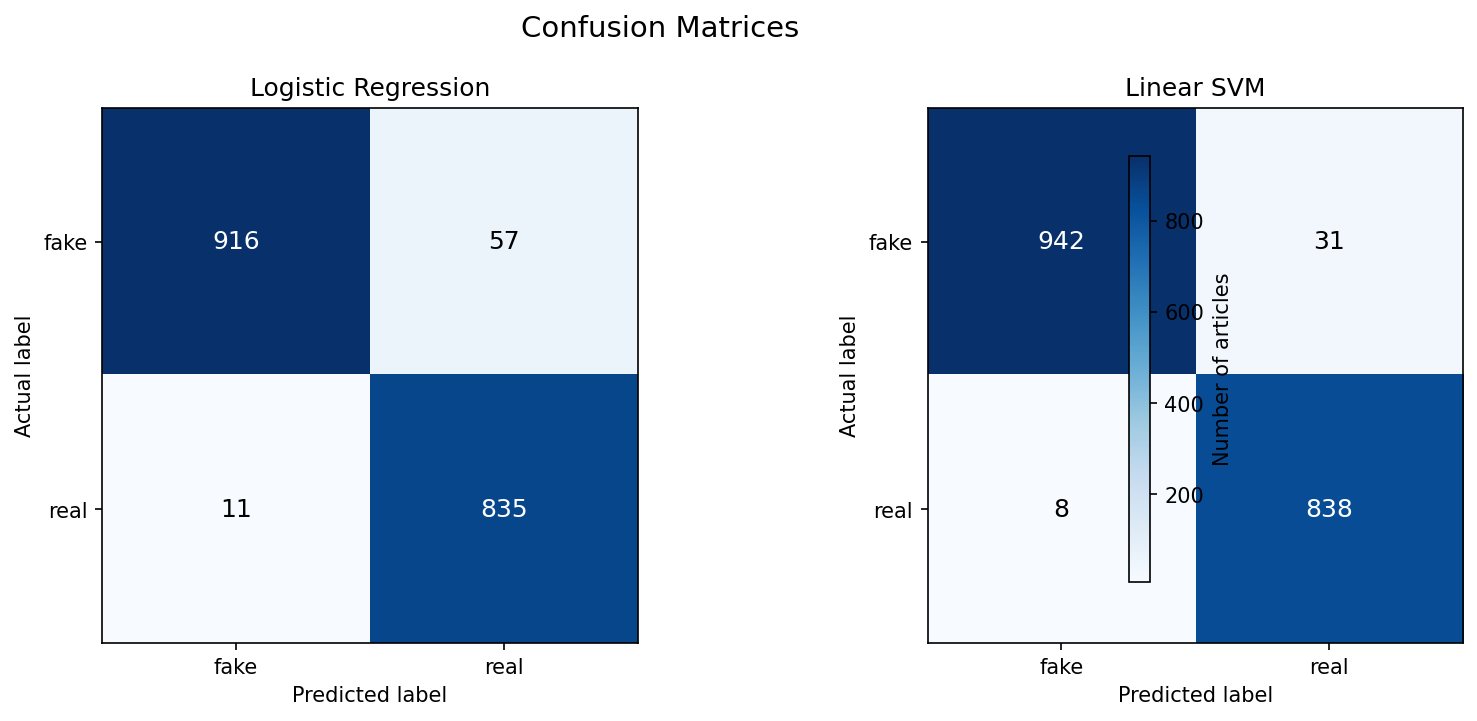

In [3]:
# Confusion matrices: rows are actual labels; columns are model predictions.
labels = metrics['labels']
fig, axes = plt.subplots(1, len(models), figsize=(11, 4.5))
if len(models) == 1:
    axes = [axes]
for ax, (key, result) in zip(axes, models.items()):
    matrix = result['confusion_matrix_rows_true_columns_predicted']
    image = ax.imshow(matrix, cmap='Blues')
    ax.set_title(names.get(key, key))
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('Actual label')
    ax.set_xticks(range(len(labels)), labels=labels)
    ax.set_yticks(range(len(labels)), labels=labels)
    threshold = max(max(row) for row in matrix) / 2
    for row in range(len(labels)):
        for col in range(len(labels)):
            ax.text(col, row, matrix[row][col], ha='center', va='center', color='white' if matrix[row][col] > threshold else 'black', fontsize=12)
fig.colorbar(image, ax=axes, shrink=0.82, label='Number of articles')
fig.suptitle('Confusion Matrices', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Reading these results

Accuracy is the fraction of correct predictions. Macro F1 averages the fake and real F1 scores equally. A confusion matrix shows correct predictions on its diagonal and mistakes off the diagonal. These are scores from a random holdout split; publisher-disjoint evaluation is a stronger next check for generalization.